# Исследование нелинейного МНК

In [1]:
from testing import testing
import numpy as np
import matplotlib.pyplot as plt

## Исследование стабильности критерия

Интервальный ряд критериев. Его статистические параметры.

Бесшумные данные. 45 поворотов. 30 итераций.

Выборочное мат. ожидание:  1.081152352829425e-12
Выборочное СКО:  1.736835018280927e-11


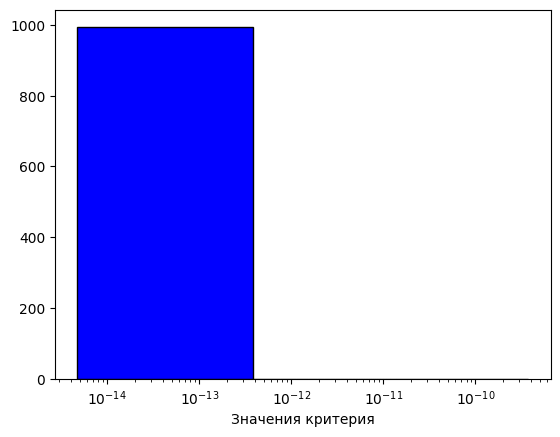

In [2]:
res = []
for j in range(1000):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 100, 0], func_params=[30])
    res.append(crit)

plt.hist(res, color='blue', edgecolor='black', bins=1000)
plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

## Исследование относительной ошибки коэффициентов

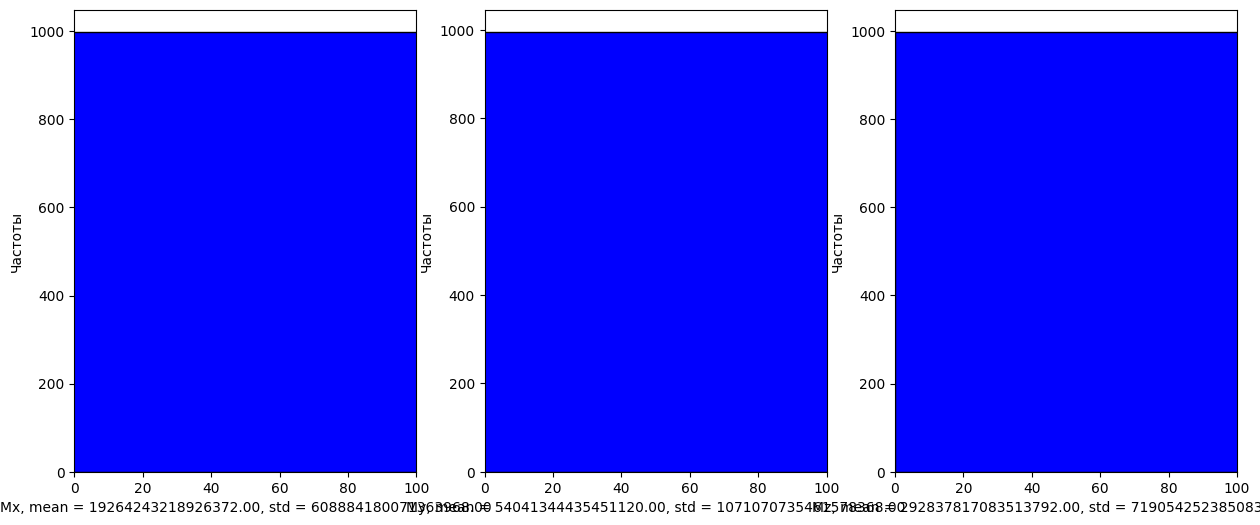

In [6]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z']

for j in range(1000):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 100, 0], func_params=[30])
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

plt.figure(figsize=(15, 6))
# plt.title('Вариационный ряд масштабных коэффициентов')
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 100, 1)
    plt.hist(res[axis_name[i]], color='blue', edgecolor='black')
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')
# plt.show()

## Иследование на количество итераций

Зависимотсть среднего критерия от числа итераций алгоритма. 

Бесшумные данные. 45 поворотов.

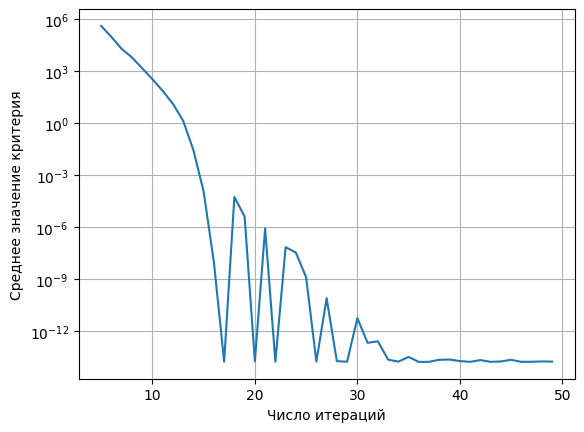

In [4]:
iter_num = 50
model_num = 100

x = range(5, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 100, 0], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()